# Project: Spatial Prediction of Dengue Clusters in Singapore
### SC3021 DSF Lab
**Team:** Jerome, Sathwiik, Marvin

**Research Question:**
Can we predict the emergence and intensity of dengue clusters 2 weeks in advance by analysing localised weather patterns and historical case trends?

## 0. Setup

In [ ]:
# === GRADER SETUP: run this cell first, then Runtime → Run all ===
import os, subprocess, sys, shutil

DOWNLOAD_DIR = '/content/DSFLab_download'
DATA_DIR     = '/content/DSFLab_data'

ZIP_FILE_IDS = [
    '1jNCJtcg0_U2S581Lg7s7ENjMGuyImELY',
    '1kmf_Nkv3ffRhjdCwOvm8UJtGBVyyWdqg',
]

if not os.path.isdir(DATA_DIR) or not os.listdir(DATA_DIR):
    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'], check=True)
    for i, fid in enumerate(ZIP_FILE_IDS, 1):
        zip_path = f'/content/part_{i}.zip'
        subprocess.run(['gdown', fid, '-O', zip_path], check=True)
        subprocess.run(['unzip', '-q', '-o', zip_path, '-d', DOWNLOAD_DIR], check=True)

    entries = os.listdir(DOWNLOAD_DIR)
    if len(entries) == 1 and os.path.isdir(os.path.join(DOWNLOAD_DIR, entries[0])):
        shutil.move(os.path.join(DOWNLOAD_DIR, entries[0]), DATA_DIR)
    else:
        shutil.move(DOWNLOAD_DIR, DATA_DIR)

print('Data ready at', DATA_DIR)
print('Contents:', sorted(os.listdir(DATA_DIR))[:15])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Paths — names match downstream cells ===
DENGUE_FOLDERS = [
    os.path.join(DATA_DIR, 'sgcharts/csv'),
    os.path.join(DATA_DIR, 'sgcharts/incorrect_latitude_longitude'),
]
RAINFALL_2016_FOLDER = os.path.join(DATA_DIR, 'SC3021_rainfall')
RAINFALL_HIST_FILES = [
    os.path.join(DATA_DIR, 'HistoricalRainfallacrossSingapore2017.csv.download/HistoricalRainfallacrossSingapore2017.csv'),
    os.path.join(DATA_DIR, 'HistoricalRainfallacrossSingapore2018.csv.download/HistoricalRainfallacrossSingapore2018.csv'),
    os.path.join(DATA_DIR, 'HistoricalRainfallacrossSingapore2019.csv.download/HistoricalRainfallacrossSingapore2019.csv'),
    os.path.join(DATA_DIR, 'HistoricalRainfallacrossSingapore2020.csv.download/HistoricalRainfallacrossSingapore2020.csv'),
]
WEATHER_FILES = [
    os.path.join(DATA_DIR, 'Historical4dayWeatherForecast2016.csv'),
    os.path.join(DATA_DIR, 'Historical4dayWeatherForecast2017.csv'),
    os.path.join(DATA_DIR, 'Historical4dayWeatherForecast2018.csv'),
    os.path.join(DATA_DIR, 'Historical4dayWeatherForecast2019.csv'),
    os.path.join(DATA_DIR, 'Historical4dayWeatherForecast2020.csv'),
]
URA_FILE      = os.path.join(DATA_DIR, 'ura_subzones.geojson')
BULLETIN_FILE = os.path.join(DATA_DIR, 'WeeklyInfectiousDiseaseBulletinCases.csv')


Data ready at /content/DSFLab_data
Contents: ['.DS_Store', 'Historical4dayWeatherForecast2016.csv', 'Historical4dayWeatherForecast2017.csv', 'Historical4dayWeatherForecast2018.csv', 'Historical4dayWeatherForecast2019.csv', 'Historical4dayWeatherForecast2020.csv', 'HistoricalRainfallacrossSingapore2017.csv.download', 'HistoricalRainfallacrossSingapore2018.csv.download', 'HistoricalRainfallacrossSingapore2019.csv.download', 'HistoricalRainfallacrossSingapore2020.csv.download', 'SC3021_rainfall', 'WeeklyInfectiousDiseaseBulletinCases.csv', 'sgcharts']


---
## 1. Data Science Problem Formulation (The Ask)

###The Context
Dengue management in Singapore is largely reactive. Vector control measures are usually implemented only after dengue cases are reported or clusters have already been formed. By this stage, transmission has already begun, making it harder to contain the spread effectively.

###The Research Question
Can we predict the emergence and intensity of dengue clusters **2 to 4 weeks in advance** by using localised weather data and historical case trends?

###Decision-Making Support
This project aims to shift dengue control from a reactive approach to a more proactive one. By identifying areas that are likely to experience outbreaks based on weather patterns (such as heavy rainfall followed by warm conditions), agencies like NEA can intervene earlier. This could include deploying Gravitraps or inspection teams to high-risk areas before clusters fully develop.





## 2. Requirement Analysis (The Prepare)
To address our research question, we considered both domain-specific and technical requirements that guide how the data should be structured and used.

### Domain Constraints (Biological Logic)

-**Time-Lag Effect**
Weather conditions do not immediately lead to dengue cases. There is a natural delay of about **14-21 days**, which accounts for mosquito breeding and virus incubation. This means weather features must be time-shifted to reflect their delayed impact on case counts.

-**Localised Analysis**
Dengue outbreaks vary across different areas in Singapore. Using only national-level averages would not capture these differences. Therefore, the analysis must be done at a more detailed level, such as **URA subzones**, to reflect local transmission patterns.

-**Assumption of Case Origin**
The datasets we plan on using capture the patient's home location, so our model and data will be built with the assumption that dengue was caught at that residential area.

### Technical Constraints

-**Temporal Alignment**
Weather data is recorded daily, while dengue case data is reported weekly. To ensure consistency, all data needs to be aligned to a common time format, specifically **ISO epidemiological weeks**.

-**Data Integration**
The project involved combining different types of data:

-Spatial data (URA subzones in GeoJSON format)

-Time-series data (weather and dengue cases in CSV format)

These datasets must be processed and merged carefully to ensure that both spatial and temporal relationships are preserved.

---
## 3. Identified Data Sources

To support our analysis, we use four main data sources split across dengue case records and meteorological predictors, plus one spatial reference layer.

---

### Dengue Case Data (2 Sources)

#### Source 1: SGCharts Historical Dengue Cluster Snapshots
* **Name:** SGCharts Historical Dengue Cluster Snapshots (sourced from NEA official disclosures)
* **Source:** `https://outbreak.sgcharts.com/data` — Google Drive CSV archive
* **Format:** `CSV` (geocoded, one file per snapshot date; 9-column schema: address, lat/lon, case counts, cluster ID)
* **Temporal Range:** May 2013 – November 2020
* **Spatial Resolution:** Geocoded to street-address / apartment-block level (lat/lon), spatial-joined to URA Subzones, every 4–8 days
* **Relevance:** The only publicly available historical time-series of individual dengue cluster locations in Singapore. Used in peer-reviewed research (e.g., Chen et al., 2022, *Scientific Data*).

#### Source 2: MOH National Weekly Dengue Bulletin
* **Name:** Ministry of Health Weekly Infectious Disease Bulletin
* **Source:** MOH Singapore — national weekly disease reporting
* **Format:** `CSV` (one row per disease per epi-week; fields: `epi_week`, `disease`, `no._of_cases`)
* **Temporal Range:** 2016 – 2020 ✅ overlaps with study window
* **Spatial Resolution:** National aggregate only (island-wide total)
* **Relevance:** Provides Singapore-wide weekly case baseline used to contextualise subzone-level cluster intensity.

---

### Predictors — Weather Data (2 Sources)

#### Source 3.1: Historical Rainfall across Singapore
* **Name:** Historical Daily Rainfall per Station
* **Source:** National Environment Agency via Data.gov.sg
* **Format:** `CSV` (one row per station per day; `SC3021_rainfall/` folder for 2016)
* **Temporal Range:** 2017 – 2020 ,main part of study window
* **Spatial Resolution:** Named weather stations across Singapore, Thiessen-polygon assigned to URA subzones

#### Source 3.2: Historical Daily Rainfall Records
* **Name:** Historical Daily Rainfall per Station
* **URL:** https://www.weather.gov.sg/climate-historical-daily/
* **Format:** `CSV` (one row per station per day; `SC3021_rainfall/` folder for 2016)
* **Temporal Range:** 2016 – 2020 , fills gap of study window as 2016 has a lot of dengue cases to use
* **Spatial Resolution:** Named weather stations across Singapore, Thiessen-polygon assigned to URA subzones

#### Source 4: Historical 4-Day Weather Forecast Records
* **Name:** Historical 4-Day Weather Forecast (Temperature & Humidity)
* **Source:** National Environment Agency via Data.gov.sg
* **Format:** `CSV` (one row per forecast date; fields: `forecast_date`, `temperature_high`, `temperature_low`, `relative_humidity_high`, `relative_humidity_low`)
* **Temporal Range:** 2016 – 2020 ✅ overlaps with study window
* **Spatial Resolution:** Island-wide forecast (no station granularity)

---

### Spatial Join Key

#### Source 5: URA Master Plan 2019 Subzone Boundaries
* **Name:** Master Plan 2019 Subzone Boundary (No Sea)
* **Source:** Urban Redevelopment Authority via Data.gov.sg
* **API Dataset ID:** `d_8594ae9ff96d0c708bc2af633048edfb`
* **Format:** `GeoJSON`
* **Coverage:** 332 subzones across 55 planning areas and 5 regions (stable across 2016–2020)

---
## 4. Data Exploration

We load each raw dataset, inspect its structure, and plot key trends. No cleaning or merging happens in this section.

### 4.1 S1 — Weather Data

**Rainfall 2016** — daily totals per station (`SC3021_rainfall` folder, one CSV per station per month)

**Rainfall 2017–2020** — 5-minute sensor readings per station, aggregated to daily totals on load to keep memory manageable

**Temperature & Humidity** — Historical 4-day weather forecasts 2016–2020, one row per forecast date

In [ ]:
# Load 2016 rainfall — filename format: DAILYDATA_S{station}_{YYYYMM}.csv
rain_2016_frames = []
for f in sorted(glob.glob(os.path.join(RAINFALL_2016_FOLDER, '*.csv'))):
    parts      = os.path.basename(f).replace('.csv', '').split('_')
    station_id = parts[1]
    df = pd.read_csv(f, encoding='latin1')
    df.columns = df.columns.str.strip()
    rainfall_col = [c for c in df.columns if 'Rainfall' in c and 'Daily' in c][0]
    df = df.rename(columns={rainfall_col: 'daily_rainfall_mm', 'Station': 'station_name'})
    df['date']              = pd.to_datetime(df[['Year', 'Month', 'Day']])
    df['station_id']        = station_id
    df['daily_rainfall_mm'] = pd.to_numeric(df['daily_rainfall_mm'], errors='coerce').fillna(0)
    rain_2016_frames.append(df[['date', 'station_id', 'station_name', 'daily_rainfall_mm']])

rain_2016 = pd.concat(rain_2016_frames, ignore_index=True)
print(f'2016 rainfall: {len(rain_2016):,} rows, {rain_2016["station_id"].nunique()} stations')
print(rain_2016.head(3).to_string())

print(rain_2016['daily_rainfall_mm'].describe())

2016 rainfall: 17,476 rows, 60 stations
        date station_id station_name  daily_rainfall_mm
0 2016-03-01        S06   Paya Lebar                0.0
1 2016-03-02        S06   Paya Lebar                0.0
2 2016-03-03        S06   Paya Lebar                0.0
count    17476.000000
mean         5.962537
std         12.521815
min          0.000000
25%          0.000000
50%          0.200000
75%          5.600000
max        217.000000
Name: daily_rainfall_mm, dtype: float64


Rainfall in the range 0 to 217 mm per day per locale is acceptable for Singapore and not erronous.

In [ ]:
# Load 2017–2020 rainfall — 5-minute readings summed to daily totals per station on load
rain_hist_frames      = []
station_lookup_frames = []

for f in RAINFALL_HIST_FILES:
    df = pd.read_csv(f, usecols=[
        'date', 'station_id', 'station_name',
        'location_longitude', 'location_latitude', 'reading_value'
    ])
    df['date']          = pd.to_datetime(df['date'])
    df['reading_value'] = pd.to_numeric(df['reading_value'], errors='coerce').fillna(0)

    station_lookup_frames.append(
        df[['station_id', 'station_name', 'location_longitude', 'location_latitude']]
        .drop_duplicates('station_id')
    )
    daily = df.groupby(['date', 'station_id', 'station_name'])['reading_value'].sum().reset_index()
    daily.rename(columns={'reading_value': 'daily_rainfall_mm'}, inplace=True)
    rain_hist_frames.append(daily)

rain_hist      = pd.concat(rain_hist_frames, ignore_index=True)
station_lookup = pd.concat(station_lookup_frames).drop_duplicates('station_id').reset_index(drop=True)

print(f'2017-2020 rainfall: {len(rain_hist):,} rows, {rain_hist["station_id"].nunique()} stations')
print(rain_hist.head(3).to_string())

print(rain_hist['daily_rainfall_mm'].describe())

2017-2020 rainfall: 78,012 rows, 91 stations
        date station_id        station_name  daily_rainfall_mm
0 2017-01-01        S06                 S06                3.2
1 2017-01-01        S07         Lornie Road               14.4
2 2017-01-01        S08  Upper Thomson Road                3.0
count    78012.000000
mean         6.238328
std         13.076677
min          0.000000
25%          0.000000
50%          0.200000
75%          6.000000
max        185.200020
Name: daily_rainfall_mm, dtype: float64


Rainfall in the range 0 to 185 mm per day per locale is also acceptable for Singapore and not erronous.

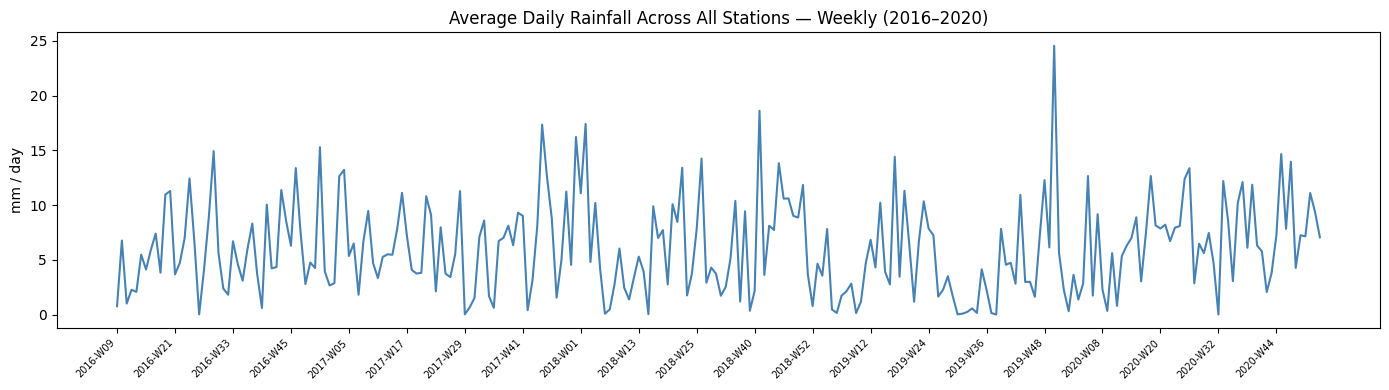

In [ ]:
# Quick look at rainfall across the full study period — island-wide weekly average
rain_preview = pd.concat(
    [rain_2016, rain_hist[['date', 'station_id', 'station_name', 'daily_rainfall_mm']]],
    ignore_index=True
)
rain_preview = rain_preview[(rain_preview['date'] >= DATE_START) & (rain_preview['date'] <= DATE_END)]
rain_preview = rain_preview[rain_preview['station_id'] != 'S82']
rain_preview['year']     = rain_preview['date'].dt.isocalendar().year.astype(int)
rain_preview['iso_week'] = rain_preview['date'].dt.isocalendar().week.astype(int)

island_rain = (
    rain_preview.groupby(['year', 'iso_week'])['daily_rainfall_mm']
    .mean().reset_index()
)
island_rain['label'] = island_rain['year'].astype(str) + '-W' + island_rain['iso_week'].astype(str).str.zfill(2)

plt.figure(figsize=(14, 4))
plt.plot(range(len(island_rain)), island_rain['daily_rainfall_mm'], color='steelblue')
plt.xticks(
    range(0, len(island_rain), 12),
    island_rain['label'].iloc[::12],
    rotation=45, ha='right', fontsize=7
)
plt.title('Average Daily Rainfall Across All Stations — Weekly (2016–2020)')
plt.ylabel('mm / day')
plt.tight_layout()
plt.show()

In [ ]:
# Load temperature and humidity from the Historical 4-day weather forecast files
weather_frames = []
for f in FORECAST_FILES:
    df = pd.read_csv(f)
    df['forecast_date'] = pd.to_datetime(df['forecast_date'])
    weather_frames.append(df[[
        'forecast_date',
        'temperature_high', 'temperature_low',
        'relative_humidity_high', 'relative_humidity_low'
    ]])

weather_raw = pd.concat(weather_frames, ignore_index=True)
weather_raw = weather_raw[
    (weather_raw['forecast_date'] >= DATE_START) &
    (weather_raw['forecast_date'] <= DATE_END)
]
print(f'Weather rows: {len(weather_raw):,}')
print(weather_raw.describe().round(2))


Weather rows: 15,387
                       forecast_date  temperature_high  temperature_low  \
count                          15387          15387.00         15387.00   
mean   2018-08-31 05:21:39.200623616             33.14            24.45   
min              2016-03-20 00:00:00             26.00            12.00   
25%              2017-06-07 00:00:00             33.00            24.00   
50%              2018-09-15 00:00:00             33.00            24.00   
75%              2019-11-22 00:00:00             34.00            25.00   
max              2020-12-31 00:00:00             35.00            27.00   
std                              NaN              1.03             0.76   

       relative_humidity_high  relative_humidity_low  
count                15387.00               15387.00  
mean                    93.92                  58.47  
min                     40.00                  10.00  
25%                     95.00                  55.00  
50%                     95.0

We clean the data of erronous records based on standard Singapore temperature and humidity ranges.

In [ ]:
# Define cleaning bounds
TEMP_HIGH_MIN,  TEMP_HIGH_MAX  = 26, 37
TEMP_LOW_MIN,   TEMP_LOW_MAX   = 22, 30
HUM_HIGH_MIN,   HUM_HIGH_MAX   = 70, 100
HUM_LOW_MIN,    HUM_LOW_MAX    = 40, 100

# Count outliers before cleaning
out_temp_high = weather_raw['temperature_high'].between(TEMP_HIGH_MIN, TEMP_HIGH_MAX)
out_temp_low  = weather_raw['temperature_low'].between(TEMP_LOW_MIN,   TEMP_LOW_MAX)
out_hum_high  = weather_raw['relative_humidity_high'].between(HUM_HIGH_MIN, HUM_HIGH_MAX)
out_hum_low   = weather_raw['relative_humidity_low'].between(HUM_LOW_MIN,   HUM_LOW_MAX)

print(f'temperature_high outside range:      {(~out_temp_high).sum():,}')
print(f'temperature_low outside range:       {(~out_temp_low).sum():,}')
print(f'relative_humidity_high outside range:{(~out_hum_high).sum():,}')
print(f'relative_humidity_low outside range: {(~out_hum_low).sum():,}')

# Apply cleaning — drop rows with any out-of-range values
weather_clean = weather_raw[
    out_temp_high & out_temp_low & out_hum_high & out_hum_low
].copy()

print(f'\nBefore: {len(weather_raw):,} rows')
print(f'After:  {len(weather_clean):,} rows')
print(f'Dropped:{len(weather_raw) - len(weather_clean):,} rows')
print(weather_clean.describe().round(2))

temperature_high outside range:      0
temperature_low outside range:       6
relative_humidity_high outside range:3
relative_humidity_low outside range: 5

Before: 15,387 rows
After:  15,374 rows
Dropped:13 rows
                       forecast_date  temperature_high  temperature_low  \
count                          15374          15374.00         15374.00   
mean   2018-08-31 04:45:29.387277056             33.14            24.45   
min              2016-03-20 00:00:00             26.00            22.00   
25%              2017-06-06 06:00:00             33.00            24.00   
50%              2018-09-15 12:00:00             33.00            24.00   
75%              2019-11-22 00:00:00             34.00            25.00   
max              2020-12-31 00:00:00             35.00            27.00   
std                              NaN              1.03             0.75   

       relative_humidity_high  relative_humidity_low  
count                15374.00               15374.00  
m

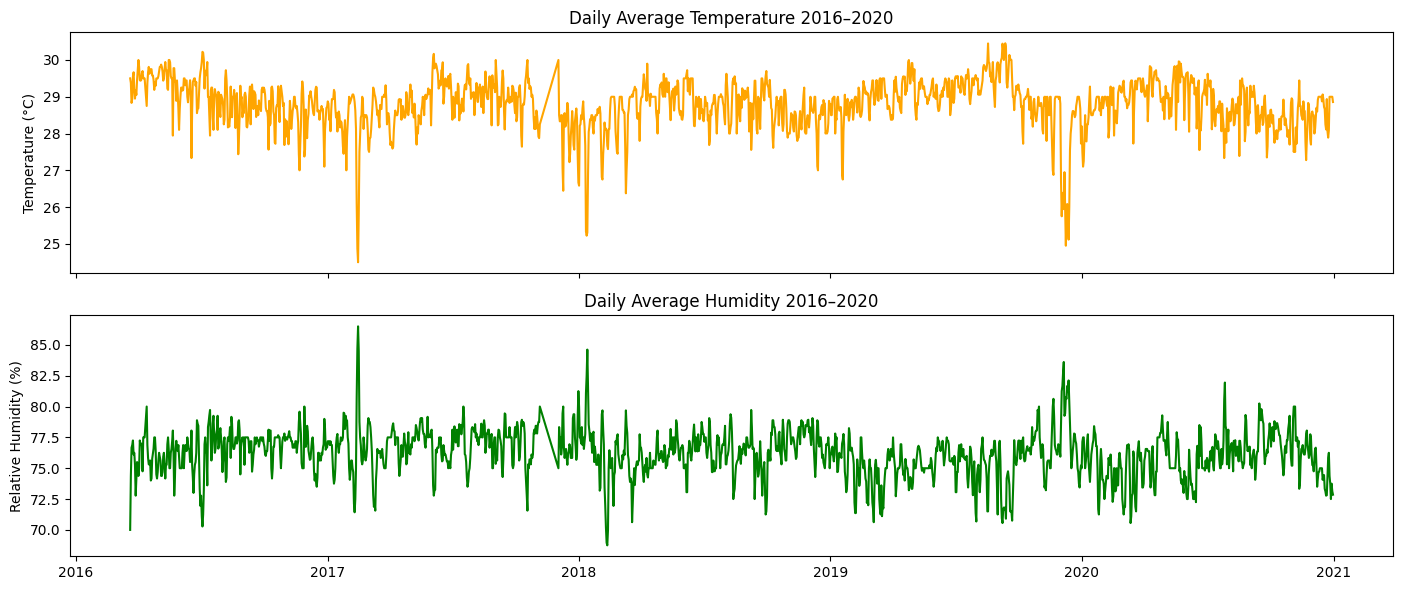

In [ ]:
# Plot temperature and humidity across the study period
weather_daily = weather_clean.groupby('forecast_date').mean(numeric_only=True).reset_index()
weather_daily['temp_avg']     = (weather_daily['temperature_high'] + weather_daily['temperature_low']) / 2
weather_daily['humidity_avg'] = (weather_daily['relative_humidity_high'] + weather_daily['relative_humidity_low']) / 2

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(weather_daily['forecast_date'], weather_daily['temp_avg'], color='orange')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title('Daily Average Temperature 2016–2020')
axes[1].plot(weather_daily['forecast_date'], weather_daily['humidity_avg'], color='green')
axes[1].set_ylabel('Relative Humidity (%)')
axes[1].set_title('Daily Average Humidity 2016–2020')
plt.tight_layout()
plt.show()

### 4.2 S2 — Dengue Case Data

**SGCharts snapshots** — point-in-time dengue cluster records scraped from the NEA live map, one CSV per snapshot date. Each row is one cluster address with case counts.

**National bulletin** — MOH weekly report of total dengue cases across all of Singapore.

In [ ]:
# Load all SGCharts dengue cluster CSVs from both folders
DENGUE_COLS = [
    'cases_in_location', 'address', 'latitude', 'longitude',
    'recent_cases_last_2_weeks', 'cluster_total_cases',
    'cluster_id', 'snapshot_yymmdd', 'active_cluster_count'
]

frames = []
for folder in DENGUE_FOLDERS:
    for f in sorted(glob.glob(os.path.join(folder, '*.csv'))):
        date_part = os.path.basename(f).split('-')[0]
        try:
            snap_date = pd.to_datetime(date_part, format='%y%m%d')
        except ValueError:
            continue
        df = pd.read_csv(f, header=None, encoding='utf-8')
        df = df.dropna(how='all')
        if len(df.columns) != 9:
            continue
        df.columns = DENGUE_COLS
        df['snapshot_date'] = snap_date
        frames.append(df)

dengue_raw = pd.concat(frames, ignore_index=True)
print(f'Loaded {len(dengue_raw):,} rows across {dengue_raw["snapshot_date"].nunique()} snapshots')
print(f'Date range: {dengue_raw["snapshot_date"].min().date()} → {dengue_raw["snapshot_date"].max().date()}')
print(dengue_raw.head(3).to_string())

Loaded 73,953 rows across 347 snapshots
Date range: 2013-05-23 → 2020-11-06
   cases_in_location                       address  latitude   longitude  recent_cases_last_2_weeks  cluster_total_cases  cluster_id  snapshot_yymmdd  active_cluster_count snapshot_date
0                  4  bishan street 22 (block 232)  1.358286  103.845226                          1                   24          83           150703                     7    2015-07-03
1                  7  bishan street 22 (block 233)  1.358639  103.845259                          1                   24          83           150703                     7    2015-07-03
2                  3  bishan street 22 (block 234)  1.358390  103.845955                          1                   24          83           150703                     7    2015-07-03


In [ ]:
print('=== Shape ===')
print(dengue_raw.shape)
print('\n=== Missing Values ===')
print(dengue_raw.isnull().sum())
print('\n=== Snapshots per Year ===')
print(dengue_raw.groupby(dengue_raw['snapshot_date'].dt.year)['snapshot_date'].nunique())

print('\n=== Min/Max by Year ===')
print(dengue_raw.groupby(dengue_raw['snapshot_date'].dt.year)['cases_in_location'].agg(['min', 'max', 'mean']).round(2))

=== Shape ===
(73953, 10)

=== Missing Values ===
cases_in_location            0
address                      0
latitude                     0
longitude                    0
recent_cases_last_2_weeks    0
cluster_total_cases          0
cluster_id                   0
snapshot_yymmdd              0
active_cluster_count         0
snapshot_date                0
dtype: int64

=== Snapshots per Year ===
snapshot_date
2013    25
2014    42
2015    57
2016    51
2017    50
2018    53
2019    42
2020    27
Name: snapshot_date, dtype: int64

=== Min/Max by Year ===
               min  max  mean
snapshot_date                
2013             1  108  2.57
2014             1  187  3.23
2015             1   81  2.04
2016             1   82  2.22
2017             1   23  2.07
2018             1   64  2.61
2019             1   67  2.54
2020             1  104  3.04


Upto 187 cases in a week in a locale is reasonable, taking into account the spike in 2020 and therefore not erronous.

In [ ]:
# Load the MOH national weekly dengue bulletin
bulletin_raw = pd.read_csv(BULLETIN_FILE)
print(f'Bulletin rows: {len(bulletin_raw):,}')
print('Disease types:', bulletin_raw['disease'].unique())
print(bulletin_raw.head(4).to_string())

Bulletin rows: 20,070
Disease types: ['Acute Viral hepatitis B' 'Acute Viral hepatitis C' 'Avian Influenza'
 'Campylobacterenterosis' 'Chikungunya Fever' 'Cholera' 'Dengue Fever'
 'Dengue Haemorrhagic Fever' 'Diphtheria' 'Encephalitis'
 'Haemophilus influenzae type b' 'Hand, Foot Mouth Disease'
 'Legionellosis' 'Malaria' 'Measles' 'Melioidosis'
 'Meningococcal Infection' 'Mumps' 'Nipah virus infection' 'Paratyphoid'
 'Pertussis' 'Plague' 'Pneumococcal Disease (invasive)' 'Poliomyelitis'
 'Rubella' 'Salmonellosis(non-enteric fevers)' 'SARS' 'Typhoid'
 'Viral Hepatitis A' 'Viral Hepatitis E' 'Yellow Fever'
 'Zika Virus Infection' 'Acute Viral Hepatitis A'
 'Acute Viral Hepatitis E' 'Chikungunya' 'HFMD' 'Nipah'
 'Campylobacter enteritis' 'Leptospirosis' 'Zika' 'Ebola Virus Disease'
 'Japanese Encephalitis' 'Tetanus' 'Botulism' 'Murine Typhus' 'Monkeypox']
   epi_week                  disease  no._of_cases
0  2012-W01  Acute Viral hepatitis B             0
1  2012-W01  Acute Viral hepatiti

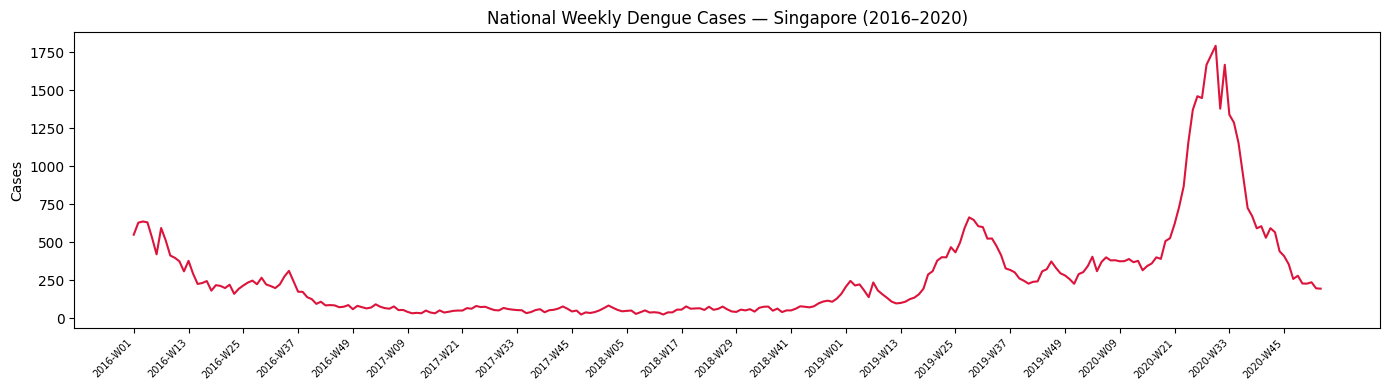

In [ ]:
# Plot national weekly dengue trend across the study period
bulletin_dengue = (
    bulletin_raw[bulletin_raw['disease'].str.contains('Dengue', case=False)]
    .groupby('epi_week')['no._of_cases'].sum()
    .reset_index()
)
bulletin_dengue['year']     = bulletin_dengue['epi_week'].str[:4].astype(int)
bulletin_dengue['iso_week'] = bulletin_dengue['epi_week'].str[6:].astype(int)
bulletin_dengue = bulletin_dengue[
    (bulletin_dengue['year'] >= 2016) & (bulletin_dengue['year'] <= 2020)
].sort_values(['year', 'iso_week']).reset_index(drop=True)

bulletin_dengue['label'] = (
    bulletin_dengue['year'].astype(str) + '-W' +
    bulletin_dengue['iso_week'].astype(str).str.zfill(2)
)

plt.figure(figsize=(14, 4))
plt.plot(range(len(bulletin_dengue)), bulletin_dengue['no._of_cases'], color='crimson')
plt.xticks(
    range(0, len(bulletin_dengue), 12),
    bulletin_dengue['label'].iloc[::12],
    rotation=45, ha='right', fontsize=7
)
plt.title('National Weekly Dengue Cases — Singapore (2016–2020)')
plt.ylabel('Cases')
plt.tight_layout()
plt.show()

The trend shows small spikes in cases of 2016 and 2019 and a huge spike in 2020, which is what we expect based on news and real data.

### 4.3 S3 — URA Planning Boundaries

**Source:** URA Master Plan 2019 subzone boundaries (`ura_subzones.geojson` from data.gov.sg)

332 subzones across 55 planning areas and 5 regions. Used as the spatial unit for aggregating dengue cases and assigning rainfall stations.

In [ ]:
# DS3: Load URA Master Plan 2019 Subzone Boundary GeoJSON from data.gov.sg
# Dataset ID: d_8594ae9ff96d0c708bc2af633048edfb

dataset_id = "d_8594ae9ff96d0c708bc2af633048edfb"
api_url = f"https://api-open.data.gov.sg/v1/public/api/datasets/{dataset_id}/poll-download"

try:
    from google.colab import userdata
    API_KEY = userdata.get("DATA_GOV_API_KEY").strip()
    headers = {"Authorization": API_KEY}
except Exception:
    headers = {}

ura_gdf = None
for attempt in range(5):
    response = requests.get(api_url, headers=headers)
    json_data = response.json()

    if json_data['code'] == 24:
        print(f"Rate limited. Waiting 15 seconds... (attempt {attempt+1}/5)")
        time.sleep(15)
        continue
    elif json_data['code'] != 0:
        print(f"Error: {json_data.get('errMsg', json_data)}")
        break
    else:
        download_url = json_data['data']['url']
        print(f"Download URL obtained: {download_url[:80]}...")
        file_response = requests.get(download_url)

        if file_response.content[:2] == b'PK':
            z = zipfile.ZipFile(io.BytesIO(file_response.content))
            geo_name = [f for f in z.namelist() if f.endswith('.geojson') or f.endswith('.json')][0]
            ura_gdf = gpd.read_file(z.open(geo_name))
        else:
            ura_gdf = gpd.read_file(io.BytesIO(file_response.content))

        print(f"\nLoaded {len(ura_gdf)} subzones x {len(ura_gdf.columns)} columns")
        print(f"Columns: {list(ura_gdf.columns)}")
        ura_gdf.head()
        break

Rate limited. Waiting 15 seconds... (attempt 1/5)
Rate limited. Waiting 15 seconds... (attempt 2/5)
Download URL obtained: https://s3.ap-southeast-1.amazonaws.com/blobs.data.gov.sg/d_8594ae9ff96d0c708bc2...

Loaded 332 subzones x 14 columns
Columns: ['OBJECTID', 'SUBZONE_NO', 'SUBZONE_N', 'SUBZONE_C', 'CA_IND', 'PLN_AREA_N', 'PLN_AREA_C', 'REGION_N', 'REGION_C', 'INC_CRC', 'FMEL_UPD_D', 'SHAPE.AREA', 'SHAPE.LEN', 'geometry']


In [ ]:
# Load URA subzone boundaries

if ura_gdf.crs is None or ura_gdf.crs.to_epsg() != 4326:
    ura_gdf = ura_gdf.set_crs(epsg=4326)

print(f'Subzones:       {len(ura_gdf)}')
print(f'Planning areas: {ura_gdf["PLN_AREA_N"].nunique()}')
print(f'Regions:        {ura_gdf["REGION_N"].nunique()}')
print(f'CRS:            {ura_gdf.crs}')
print(ura_gdf[['SUBZONE_N', 'PLN_AREA_N', 'REGION_N']].head(5).to_string())

Subzones:       332
Planning areas: 55
Regions:        5
CRS:            EPSG:4326
       SUBZONE_N     PLN_AREA_N        REGION_N
0     DEPOT ROAD    BUKIT MERAH  CENTRAL REGION
1    BUKIT MERAH    BUKIT MERAH  CENTRAL REGION
2      CHINATOWN         OUTRAM  CENTRAL REGION
3        PHILLIP  DOWNTOWN CORE  CENTRAL REGION
4  RAFFLES PLACE  DOWNTOWN CORE  CENTRAL REGION


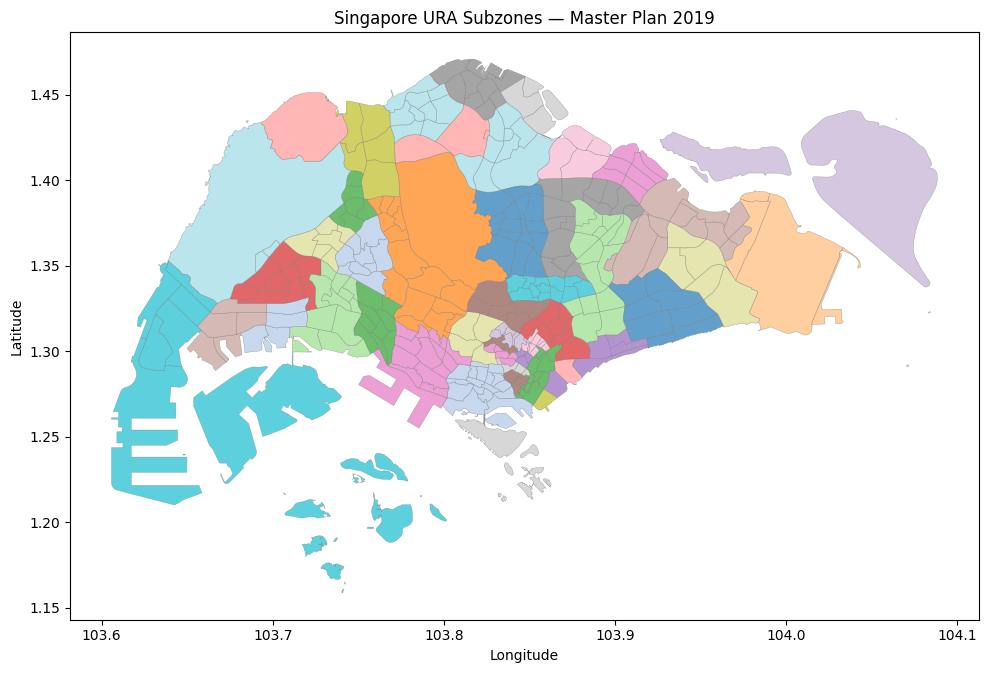

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
ura_gdf.plot(ax=ax, column='PLN_AREA_N', legend=False, cmap='tab20',
             edgecolor='grey', linewidth=0.3, alpha=0.7)
plt.title('Singapore URA Subzones — Master Plan 2019')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

---
## 5. Data Preparation

We clean each dataset, aggregate to weekly subzone level, then merge everything into one analytical table.

### 5.1 Compile Case Data

Clean the raw dengue snapshots, assign each cluster address to a URA subzone, and sum cases to one row per subzone per week. Then extract the national weekly totals from the bulletin.

In [ ]:
# Clean dengue snapshots
dengue = dengue_raw.copy()

for col in ['latitude', 'longitude', 'cases_in_location',
            'recent_cases_last_2_weeks', 'cluster_total_cases']:
    dengue[col] = pd.to_numeric(dengue[col], errors='coerce')

# Fix the one confirmed bad coordinate (upper serangoon crescent block 470a)
mask = dengue['address'] == 'upper serangoon crescent (block 470a)'
dengue.loc[mask, 'latitude']  = 1.3792
dengue.loc[mask, 'longitude'] = 103.9017

dengue = dengue[dengue['recent_cases_last_2_weeks'] >= 0]
dengue = dengue.dropna(subset=['latitude', 'longitude'])
dengue = dengue.drop_duplicates(subset=['snapshot_date', 'address', 'cluster_id'])

dengue = dengue[(dengue['snapshot_date'] >= DATE_START) & (dengue['snapshot_date'] <= DATE_END)]
dengue = dengue[
    dengue['latitude'].between(1.1, 1.5) &
    dengue['longitude'].between(103.6, 104.1)
]

dengue['year']     = dengue['snapshot_date'].dt.isocalendar().year.astype(int)
dengue['iso_week'] = dengue['snapshot_date'].dt.isocalendar().week.astype(int)

# Where multiple snapshots fall in the same ISO week, keep only the latest per address
dengue = dengue.sort_values('snapshot_date')
dengue = dengue.drop_duplicates(subset=['address', 'year', 'iso_week'], keep='last')

print(f'Clean dengue: {dengue.shape}')
print(f'Date range:   {dengue["snapshot_date"].min().date()} → {dengue["snapshot_date"].max().date()}')

Clean dengue: (46133, 12)
Date range:   2016-03-01 → 2020-11-06


Matched: 46133 / 46133


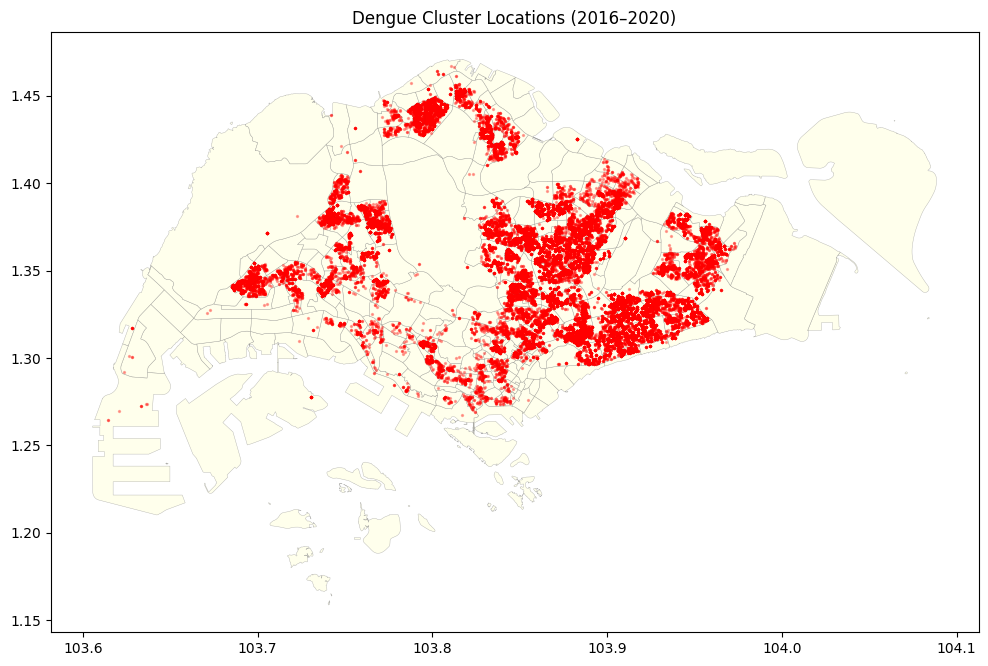

In [ ]:
# Assign each dengue address to its URA subzone using a spatial join
dengue_gdf = gpd.GeoDataFrame(
    dengue,
    geometry=gpd.points_from_xy(dengue['longitude'], dengue['latitude']),
    crs='EPSG:4326'
)
dengue_gdf = gpd.sjoin(
    dengue_gdf,
    ura_gdf[['SUBZONE_N', 'PLN_AREA_N', 'REGION_N', 'geometry']],
    how='left', predicate='within'
)
unmatched = dengue_gdf['SUBZONE_N'].isnull().sum()
print(f'Matched: {len(dengue_gdf) - unmatched} / {len(dengue_gdf)}')
dengue_gdf = dengue_gdf.dropna(subset=['SUBZONE_N'])

# Plot cleaned cluster locations
fig, ax = plt.subplots(figsize=(10, 8))
ura_gdf.plot(ax=ax, color='lightyellow', edgecolor='grey', linewidth=0.3, alpha=0.6)
dengue_gdf.plot(ax=ax, color='red', markersize=2, alpha=0.3)
plt.title('Dengue Cluster Locations (2016–2020)')
plt.tight_layout()
plt.show()

In [ ]:
# Aggregate dengue to weekly cases per subzone
dengue_weekly = (
    dengue_gdf
    .groupby(['year', 'iso_week', 'SUBZONE_N'])
    .agg(weekly_cases=('cases_in_location', 'sum'))
    .reset_index()
)
dengue_weekly['week_idx'] = dengue_weekly['year'] * 52 + dengue_weekly['iso_week']

print(f'Weekly dengue table: {dengue_weekly.shape}')
print(f'Subzones with cases: {dengue_weekly["SUBZONE_N"].nunique()}')
print(dengue_weekly.head(5).to_string(index=False))

Weekly dengue table: (6827, 5)
Subzones with cases: 243
 year  iso_week  SUBZONE_N  weekly_cases  week_idx
 2016         9   ALJUNIED            17    104841
 2016         9 ANCHORVALE             3    104841
 2016         9  BALESTIER             2    104841
 2016         9    BANGKIT             9    104841
 2016         9   BAYSHORE             2    104841


In [ ]:
# Extract national Singapore dengue total per week from the bulletin
bulletin_sg = (
    bulletin_raw[bulletin_raw['disease'].str.contains('Dengue', case=False)]
    .groupby('epi_week')['no._of_cases'].sum()
    .reset_index()
)
bulletin_sg['week_idx'] = (
    bulletin_sg['epi_week'].str[:4].astype(int) * 52 +
    bulletin_sg['epi_week'].str[6:].astype(int)
)
sg_lookup = bulletin_sg.set_index('week_idx')['no._of_cases'].to_dict()
MAX_SG    = bulletin_sg['no._of_cases'].max()

print(f'National weeks in lookup: {len(sg_lookup)}')
print(f'Max national weekly cases (used as normalisation ceiling): {MAX_SG}')

National weeks in lookup: 572
Max national weekly cases (used as normalisation ceiling): 1792


### 5.2 Compile Weather Data

Combine all rainfall years, assign each subzone to its nearest rainfall station, then aggregate to weekly values. Do the same for temperature and humidity. Compute subzone area from the URA boundaries. We assume NA means 0 rain reading. We impute all the missing humidity and temperature as it is fairly stable in Singapore and is fair to assume.

In [ ]:
rain_all = pd.concat(
    [rain_2016, rain_hist[['date', 'station_id', 'station_name', 'daily_rainfall_mm']]],
    ignore_index=True
)
rain_all = rain_all[(rain_all['date'] >= DATE_START) & (rain_all['date'] <= DATE_END)]
rain_all = rain_all[rain_all['station_id'] != 'S82']

rain_all['year']     = rain_all['date'].dt.isocalendar().year.astype(int)
rain_all['iso_week'] = rain_all['date'].dt.isocalendar().week.astype(int)

print(f'Combined rainfall: {len(rain_all):,} rows, {rain_all["station_id"].nunique()} stations')


Combined rainfall: 94,374 rows, 94 stations


In [ ]:
ura_gdf['centroid'] = ura_gdf.geometry.centroid
subzone_coords = np.array([[p.x, p.y] for p in ura_gdf['centroid']])

station_coords_df = station_lookup[
    station_lookup['station_id'].isin(rain_all['station_id'])
].dropna(subset=['location_longitude', 'location_latitude']).reset_index(drop=True)
station_coords = station_coords_df[['location_longitude', 'location_latitude']].values

tree = KDTree(station_coords)
_, idx = tree.query(subzone_coords)
ura_gdf['nearest_station_id'] = station_coords_df.iloc[idx]['station_id'].values

print(f'Subzones assigned: {len(ura_gdf)}')
print(f'Unique stations used: {ura_gdf["nearest_station_id"].nunique()}')

Subzones assigned: 332
Unique stations used: 84


In [ ]:
# Aggregate to weekly per station: total, mean daily, std daily
# rainfall_sd_daily is 0 when a station has only 1 day of data that week — this is correct
rain_weekly_station = (
    rain_all
    .groupby(['year', 'iso_week', 'station_id'])['daily_rainfall_mm']
    .agg(
        weekly_rainfall_mm  = 'sum',
        rainfall_mean_daily = 'mean',
        rainfall_sd_daily   = 'std',
    )
    .fillna(0)   # rainfall NaN means no data that week — 0 is a fair assumption
    .reset_index()
)

subzone_station_map = ura_gdf[['SUBZONE_N', 'nearest_station_id']].copy()
rain_weekly_subzone = subzone_station_map.merge(
    rain_weekly_station,
    left_on='nearest_station_id', right_on='station_id', how='left'
).drop(columns='station_id')

rain_weekly_subzone['week_idx'] = rain_weekly_subzone['year'] * 52 + rain_weekly_subzone['iso_week']

# Any subzone whose station had no data at all that week gets 0 rainfall
rain_weekly_subzone[['weekly_rainfall_mm', 'rainfall_mean_daily', 'rainfall_sd_daily']] = (
    rain_weekly_subzone[['weekly_rainfall_mm', 'rainfall_mean_daily', 'rainfall_sd_daily']].fillna(0)
)

print(f'Weekly rainfall per subzone: {rain_weekly_subzone.shape}')
print(f'Rainfall nulls remaining: {rain_weekly_subzone[["weekly_rainfall_mm","rainfall_mean_daily","rainfall_sd_daily"]].isnull().sum().sum()}')

Weekly rainfall per subzone: (50419, 8)
Rainfall nulls remaining: 0


In [ ]:
TEMP_HUM_COLS = ['temp_avg', 'temp_range', 'humidity_avg', 'humidity_range']

weather_daily_agg = weather_clean.groupby('forecast_date').mean(numeric_only=True).reset_index()
weather_daily_agg['year']          = weather_daily_agg['forecast_date'].dt.isocalendar().year.astype(int)
weather_daily_agg['iso_week']      = weather_daily_agg['forecast_date'].dt.isocalendar().week.astype(int)
weather_daily_agg['temp_avg']      = (weather_daily_agg['temperature_high'] +
weather_daily_agg['temperature_low']) / 2
weather_daily_agg['temp_range']    = weather_daily_agg['temperature_high'] - weather_daily_agg['temperature_low']
weather_daily_agg['humidity_avg']  = (weather_daily_agg['relative_humidity_high'] +
weather_daily_agg['relative_humidity_low']) / 2
weather_daily_agg['humidity_range']= weather_daily_agg['relative_humidity_high'] - weather_daily_agg['relative_humidity_low']

weather_weekly = weather_daily_agg.groupby(['year', 'iso_week']).agg(
    temp_avg      =('temp_avg',       'mean'),
    temp_range    =('temp_range',     'mean'),
    humidity_avg  =('humidity_avg',   'mean'),
    humidity_range=('humidity_range', 'mean'),
).reset_index()

# Temperature and humidity are island-wide — any missing week is a gap in the
# forecast CSV, not a station issue. Fill temporally from the nearest available week
weather_weekly = weather_weekly.sort_values(['year', 'iso_week']).reset_index(drop=True)
weather_weekly[TEMP_HUM_COLS] = weather_weekly[TEMP_HUM_COLS].ffill().bfill()

print(f'Weekly weather: {weather_weekly.shape}')
print(f'Temp/humidity nulls remaining: {weather_weekly[TEMP_HUM_COLS].isnull().sum().sum()}')
print(weather_weekly.head(5).to_string(index=False))

Weekly weather: (248, 6)
Temp/humidity nulls remaining: 0
 year  iso_week  temp_avg  temp_range  humidity_avg  humidity_range
 2016        11 29.500000   11.000000     70.000000       40.000000
 2016        12 29.216071    9.249603     76.111111       37.174603
 2016        13 29.520455    9.113925     74.938492       37.244228
 2016        14 29.531981    9.063961     76.849026       35.600649
 2016        15 29.445833    9.341667     76.666667       36.666667


In [ ]:
WEATHER_COLS = ['weekly_rainfall_mm', 'rainfall_mean_daily', 'rainfall_sd_daily',
                'temp_avg', 'temp_range', 'humidity_avg', 'humidity_range']

# Compute area in km² from Singapore's projected CRS
ura_gdf['area_km2'] = ura_gdf.to_crs(epsg=3414).geometry.area / 1e6

# Full weather lookup: all subzone-weeks with complete weather
# Used by the model to retrieve forecast-step weather
full_lookup = (
    rain_weekly_subzone
    .merge(weather_weekly, on=['year', 'iso_week'], how='left')
    .merge(ura_gdf[['SUBZONE_N', 'area_km2']], on='SUBZONE_N', how='left')
    .fillna(0)
    .set_index(['SUBZONE_N', 'week_idx'])
)

print(f'Weather lookup shape: {full_lookup.shape}')
print(f'Nulls in lookup: {full_lookup[WEATHER_COLS].isnull().sum().sum()}')


Weather lookup shape: (50419, 11)
Nulls in lookup: 0


### 5.3 Merge into Final Analytical Table

Join the case data with all weather data on subzone and week to produce one row per subzone-week with reported cases.

In [ ]:
df_active = (
    dengue_weekly
    .merge(
        rain_weekly_subzone[['SUBZONE_N', 'year', 'iso_week',
                              'weekly_rainfall_mm', 'rainfall_mean_daily', 'rainfall_sd_daily']],
        on=['SUBZONE_N', 'year', 'iso_week'], how='left'
    )
    .merge(weather_weekly, on=['year', 'iso_week'], how='left')
    .merge(ura_gdf[['SUBZONE_N', 'area_km2']], on='SUBZONE_N', how='left')
)

df_active['week_idx']       = df_active['year'] * 52 + df_active['iso_week']
df_active['sg_total_cases'] = df_active['week_idx'].map(sg_lookup).fillna(0)
df_active                   = df_active.fillna(0)

print(f'Final table: {df_active.shape}')
print(f'Nulls remaining: {df_active.isnull().sum().sum()}')
print(f'Subzones: {df_active["SUBZONE_N"].nunique()}')
print(df_active.head(5).to_string(index=False))

Final table: (6827, 14)
Nulls remaining: 0
Subzones: 243
 year  iso_week  SUBZONE_N  weekly_cases  week_idx  weekly_rainfall_mm  rainfall_mean_daily  rainfall_sd_daily  temp_avg  temp_range  humidity_avg  humidity_range  area_km2  sg_total_cases
 2016         9   ALJUNIED            17    104841                 0.2             0.033333           0.081650       0.0         0.0           0.0             0.0  2.961466             412
 2016         9 ANCHORVALE             3    104841                 0.0             0.000000           0.000000       0.0         0.0           0.0             0.0  1.496681             412
 2016         9  BALESTIER             2    104841                 0.4             0.066667           0.163299       0.0         0.0           0.0             0.0  1.926622             412
 2016         9    BANGKIT             9    104841                 0.0             0.000000           0.000000       0.0         0.0           0.0             0.0  0.763183             41

In [ ]:
before = len(df_active)
df_active = df_active.dropna(subset=WEATHER_COLS)
print(f'Dropped {before - len(df_active)} rows where weather was unavailable ({len(df_active)} remain)')

Dropped 0 rows where weather was unavailable (6827 remain)


In [ ]:
print('=== Descriptive Statistics ===')
print(df_active[[
    'weekly_cases', 'weekly_rainfall_mm', 'rainfall_mean_daily', 'rainfall_sd_daily',
    'temp_avg', 'temp_range', 'humidity_avg', 'humidity_range',
    'area_km2', 'sg_total_cases'
]].describe().round(2))

=== Descriptive Statistics ===
       weekly_cases  weekly_rainfall_mm  rainfall_mean_daily  \
count       6827.00             6827.00              6827.00   
mean          17.91               18.93                 2.75   
std           39.52               33.00                 4.78   
min            1.00                0.00                 0.00   
25%            2.00                0.00                 0.00   
50%            5.00                0.00                 0.00   
75%           15.00               27.00                 3.96   
max         1048.00              338.40                48.34   

       rainfall_sd_daily  temp_avg  temp_range  humidity_avg  humidity_range  \
count            6827.00   6827.00     6827.00       6827.00         6827.00   
mean                4.37     28.25        8.52         74.05           34.61   
std                 7.00      4.51        1.54         11.83            6.09   
min                 0.00      0.00        0.00          0.00            

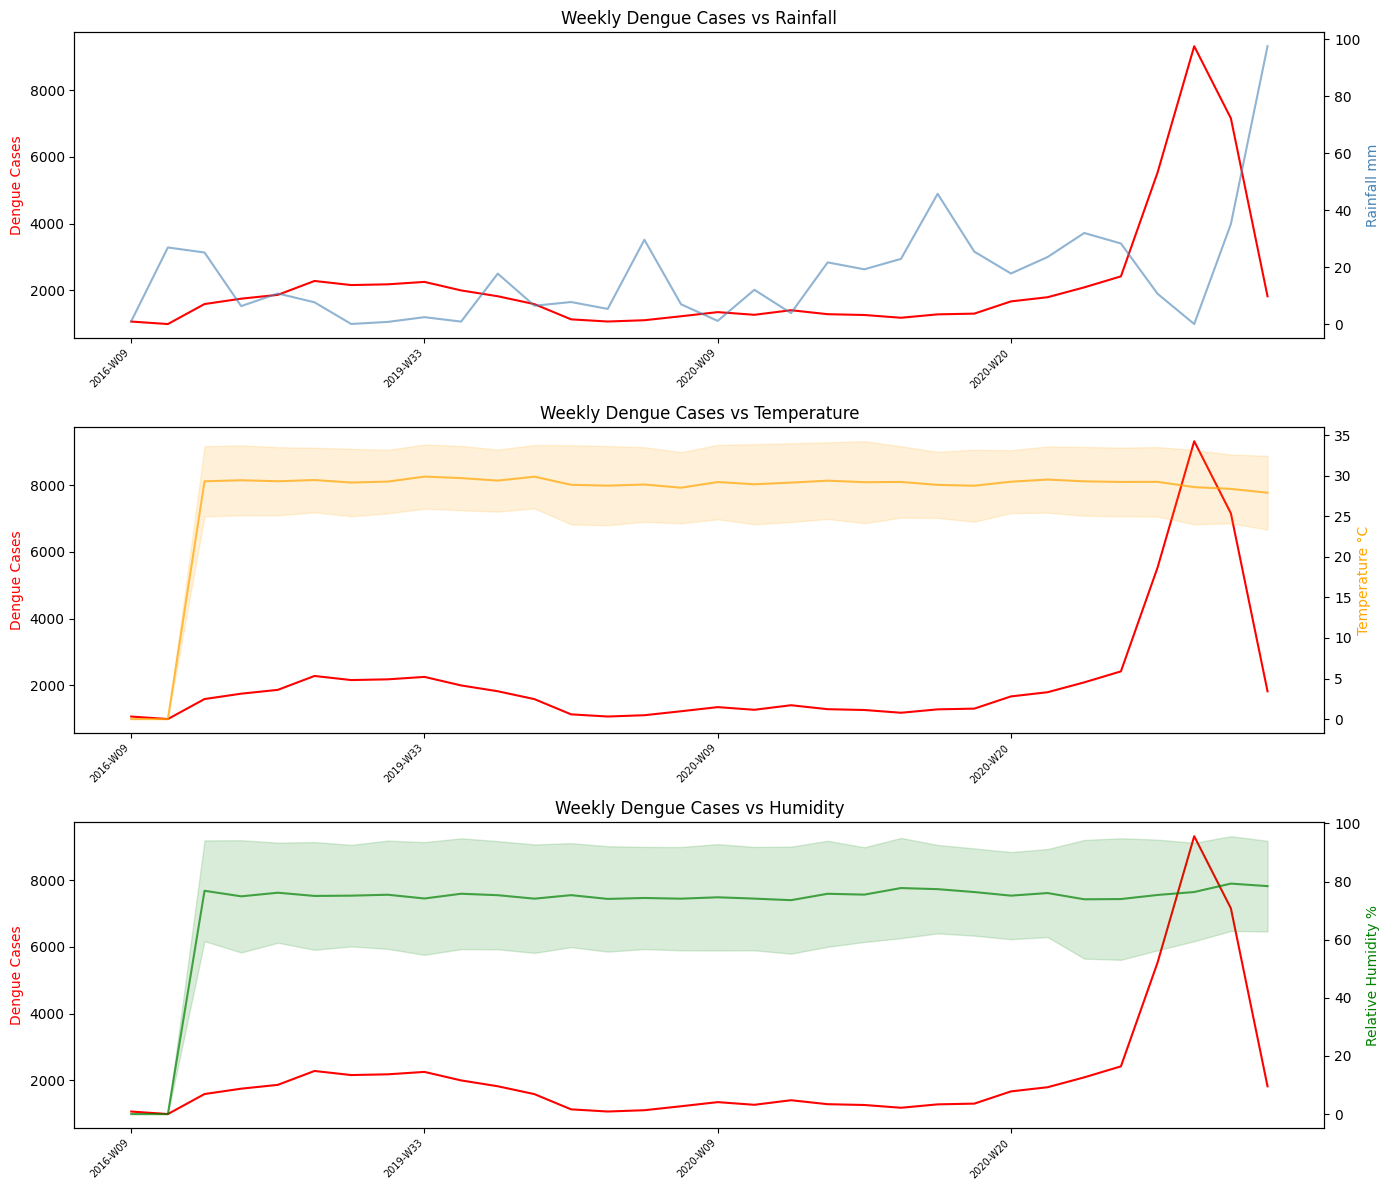

In [ ]:
# Cases vs rainfall, temperature, and humidity — island-wide weekly aggregates
island_weekly = df_active.groupby(['year', 'iso_week']).agg(
    total_cases   =('weekly_cases',        'sum'),
    avg_rainfall  =('weekly_rainfall_mm',  'mean'),
    temp_avg      =('temp_avg',            'mean'),
    temp_range    =('temp_range',          'mean'),
    humidity_avg  =('humidity_avg',        'mean'),
    humidity_range=('humidity_range',      'mean'),
).reset_index()

# Keep only weeks with full subzone coverage (drop partial boundary weeks)
week_counts = df_active.groupby(['year', 'iso_week']).size()
full_weeks = week_counts[week_counts >= week_counts.quantile(0.9) * 0.9].index
island_weekly = island_weekly.set_index(['year', 'iso_week']).loc[full_weeks].reset_index()
island_weekly = island_weekly.sort_values(['year', 'iso_week']).reset_index(drop=True)

island_weekly['label'] = (
    island_weekly['year'].astype(str) + '-W' +
    island_weekly['iso_week'].astype(str).str.zfill(2)
)
x = range(len(island_weekly))

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

ax1, ax2 = axes[0], axes[0].twinx()
ax1.plot(x, island_weekly['total_cases'],  color='red',       label='Weekly Cases')
ax2.plot(x, island_weekly['avg_rainfall'], color='steelblue', label='Avg Rainfall (mm)', alpha=0.6)
ax1.set_ylabel('Dengue Cases', color='red')
ax2.set_ylabel('Rainfall mm', color='steelblue')
axes[0].set_title('Weekly Dengue Cases vs Rainfall')
axes[0].set_xticks(list(x)[::8])
axes[0].set_xticklabels(island_weekly['label'].iloc[::8], rotation=45, ha='right', fontsize=7)

ax3, ax4 = axes[1], axes[1].twinx()
ax3.plot(x, island_weekly['total_cases'], color='red',    label='Weekly Cases')
ax4.plot(x, island_weekly['temp_avg'],    color='orange', label='Temp Avg', alpha=0.7)
ax4.fill_between(x,
    island_weekly['temp_avg'] - island_weekly['temp_range'] / 2,
    island_weekly['temp_avg'] + island_weekly['temp_range'] / 2,
    alpha=0.15, color='orange')
ax3.set_ylabel('Dengue Cases', color='red')
ax4.set_ylabel('Temperature °C', color='orange')
axes[1].set_title('Weekly Dengue Cases vs Temperature')
axes[1].set_xticks(list(x)[::8])
axes[1].set_xticklabels(island_weekly['label'].iloc[::8], rotation=45, ha='right', fontsize=7)

ax5, ax6 = axes[2], axes[2].twinx()
ax5.plot(x, island_weekly['total_cases'],  color='red',   label='Weekly Cases')
ax6.plot(x, island_weekly['humidity_avg'], color='green', label='Humidity Avg', alpha=0.7)
ax6.fill_between(x,
    island_weekly['humidity_avg'] - island_weekly['humidity_range'] / 2,
    island_weekly['humidity_avg'] + island_weekly['humidity_range'] / 2,
    alpha=0.15, color='green')
ax5.set_ylabel('Dengue Cases', color='red')
ax6.set_ylabel('Relative Humidity %', color='green')
axes[2].set_title('Weekly Dengue Cases vs Humidity')
axes[2].set_xticks(list(x)[::8])
axes[2].set_xticklabels(island_weekly['label'].iloc[::8], rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
print('Min temp_avg overall:', weather_daily['temp_avg'].min())
print('Min humidity_avg overall:', weather_daily['humidity_avg'].min())
print('Any NaN in temp_avg?', weather_daily['temp_avg'].isna().any())
print('Any NaN in humidity_avg?', weather_daily['humidity_avg'].isna().any())


Min temp_avg overall: 24.5
Min humidity_avg overall: 68.75
Any NaN in temp_avg? False
Any NaN in humidity_avg? False


---
## 6. Modelling

### 6.1 Model Plan

We use a **Transformer encoder** to predict how many dengue cases a subzone will have **2 weeks from now**.

**Why a Transformer?**
Self-attention lets the model directly relate any two weeks in the input window, so a rainfall event in week 1 and a temperature spike in week 5 can both influence the prediction together. A sequential model like an LSTM processes steps one at a time and can lose early signals before they contribute to the output.

**What goes into each prediction — an 8-step input sequence:**

| Steps | What they contain |
|-------|-------------------|
| 1–6 | Real historical weeks: local weather, national SG case count, local case count, seasonal week encoding |
| 7–8 | Forecast weeks: weather only (meteorological forecasts at this lead are reliable), case counts set to zero, a flag marks these as forecast data |

Including the 2 weeks of forecast weather closes the known biological lag — Aedes mosquito breeding plus dengue incubation takes roughly 2 weeks, so the conditions in weeks 7 and 8 directly precede the outbreak we are predicting.

**Training folds (rolling temporal split — always train on the past, test on the next year):**

| Fold | Train | Test |
|------|-------|------|
| 1 | 2016–2018 | 2019 |
| 2 | 2016–2019 | 2020 |

### 6.2 Model Preparation

Set up the sequence parameters, normalise the inputs, define the model architecture, and build the 8-step input sequences from the analytical table.

In [ ]:
# Sequence and training configuration
HIST_STEPS   = 6       # number of real historical weeks per sequence
FORE_STEPS   = 2       # number of forecast-weather steps appended
TOT_STEPS    = HIST_STEPS + FORE_STEPS   # 8 steps total
HORIZON      = 2       # predict this many weeks ahead of the last historical step
BATCH_SIZE   = 64
EPOCHS       = 200
PATIENCE     = 20
LR           = 5e-4
WEIGHT_DECAY = 1e-4

WEATHER_FEATS = [
    'weekly_rainfall_mm', 'rainfall_mean_daily', 'rainfall_sd_daily',
    'temp_avg', 'temp_range', 'humidity_avg', 'humidity_range', 'area_km2',
]
# Per step: weather(8) + sg_national(1) + local_cases(1) + forecast_flag(1) + sin_week(1) + cos_week(1) = 13
N_FEAT = len(WEATHER_FEATS) + 5

In [ ]:
# Normalisation helpers
# Case counts are highly skewed so we use log1p normalisation:
#   normalised = log(1 + x) / log(1 + max_train)  →  always in [0, 1] for training data
# Seasonal week encoding: sin/cos of ISO week number captures the annual dengue cycle

def log1p_encode(x, max_val):
    return np.log1p(np.asarray(x, dtype=float)) / np.log1p(float(max_val))

def log1p_decode(x, max_val):
    return np.expm1(np.asarray(x, dtype=float) * np.log1p(float(max_val)))

def week_sincos(week_idx):
    iso_week = week_idx % 52 or 52
    return np.sin(2 * np.pi * iso_week / 52), np.cos(2 * np.pi * iso_week / 52)

In [ ]:
# Transformer encoder model
#
# Input:  (batch, 8 steps, 13 features)
# Layers: linear projection → positional encoding → 2-layer Transformer encoder → mean pool → prediction head
# Output: one normalised case count per sample

class DengueTransformer(nn.Module):
    def __init__(self, n_feat=13, d_model=64, nhead=4, layers=2, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(n_feat, d_model)
        self.pos_enc    = nn.Parameter(torch.zeros(1, TOT_STEPS, d_model))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=128, dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(32, 1)
        )

    def forward(self, x):
        h = self.input_proj(x) + self.pos_enc
        h = self.encoder(h)
        return self.head(h.mean(dim=1)).squeeze(-1)


class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

In [ ]:
# Build 8-step input sequences from the analytical table
#
# For each subzone we slide a window over its consecutive weeks.
# Steps 1-6: real data — weather + SG national count + local cases + flag=0
# Steps 7-8: forecast data — weather only from full_lookup, cases=0, flag=1

def build_sequences(df_sub, weather_scaler, max_local_cases):
    X_list, y_list, meta = [], [], []

    for zone, grp in df_sub.groupby('SUBZONE_N'):
        grp = grp.sort_values('week_idx').reset_index(drop=True)
        n   = len(grp)
        if n < HIST_STEPS + HORIZON:
            continue

        weather_norm = weather_scaler.transform(grp[WEATHER_FEATS].values.astype(float))
        week_indices = grp['week_idx'].values
        cases_norm   = log1p_encode(grp['weekly_cases'].values, max_local_cases)
        sg_norm      = np.array([
            log1p_encode(sg_lookup.get(w, 0), MAX_SG) for w in week_indices
        ])

        for i in range(n - HIST_STEPS - HORIZON + 1):
            target_idx = i + HIST_STEPS - 1 + HORIZON

            hist_steps = []
            for j in range(i, i + HIST_STEPS):
                s, c = week_sincos(week_indices[j])
                hist_steps.append(np.concatenate([
                    weather_norm[j], [sg_norm[j], cases_norm[j], 0.0, s, c]
                ]))

            last_hist_week = week_indices[i + HIST_STEPS - 1]
            target_week    = week_indices[target_idx]

            fore_steps = []
            for fwk in [last_hist_week + 1, target_week]:
                s, c = week_sincos(fwk)
                key  = (zone, fwk)
                if key in full_lookup.index:
                    fwf = weather_scaler.transform(
                        full_lookup.loc[key][WEATHER_FEATS].values.astype(float).reshape(1, -1)
                    ).flatten()
                else:
                    fwf = np.zeros(len(WEATHER_FEATS), dtype=np.float32)
                fore_steps.append(np.concatenate([fwf, [0.0, 0.0, 1.0, s, c]]))

            X_list.append(np.array(hist_steps + fore_steps, dtype=np.float32))
            y_list.append(float(cases_norm[target_idx]))
            meta.append({
                'year':       grp.at[target_idx, 'year'],
                'SUBZONE_N':  zone,
                'actual_raw': grp.at[target_idx, 'weekly_cases'],
                'area_km2':   grp.at[target_idx, 'area_km2'],
            })

    return (
        np.array(X_list, dtype=np.float32),
        np.array(y_list,  dtype=np.float32),
        pd.DataFrame(meta).reset_index(drop=True)
    )

### 6.3 Outbreak Threshold

To decide whether a predicted case count means an **outbreak**, we compare it against a threshold built directly from the NEA epidemic definition:

> NEA defines a dengue epidemic as **30 or more cases per 100,000 population per week.**
> Singapore's average population density is approximately **8,030 people per km².**

Converting the rate to a per-km² case count:

```
K = 30 cases / 100,000 people / week  ×  8,030 people / km²  =  2.41 cases / km²
```

Each subzone gets its own threshold based on its area:

```
threshold = max(2 cases,  area_km² × 2.41)
```

The 2-case minimum is NEA's own definition of an active cluster — no subzone, however small, falls below this.

Using a fixed derived K means the same standard is applied across all folds of testing.

In [ ]:
K_FIXED   = 2.41   # 30 cases / 100,000 / week × 8,030 people / km²
NEA_FLOOR = 2.0    # NEA minimum active cluster definition

def outbreak_threshold(area_km2):
    return max(NEA_FLOOR, area_km2 * K_FIXED)

### 6.4 Training

Two temporal folds are trained independently. For each fold:
1. Fit the weather scaler and case normalisation ceiling on training years only
2. Build sequences for train and test sets
3. Train the Transformer with a weighted MSE loss that gives outbreak weeks up to 9× more influence than near-zero weeks — this prevents the model from collapsing to predicting the mean
4. Training stops early if the validation loss does not improve for 20 consecutive epochs

In [ ]:
def train_model(X, y):
    cut   = int(len(y) * 0.85)
    tr_dl = DataLoader(SeqDataset(X[:cut], y[:cut]), batch_size=BATCH_SIZE, shuffle=True)
    vl_dl = DataLoader(SeqDataset(X[cut:], y[cut:]), batch_size=BATCH_SIZE)

    model = DengueTransformer(n_feat=X.shape[2])
    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=6, factor=0.5)

    def weighted_mse(pred, target):
        # Weeks at the training maximum (normalised = 1.0) get 9x the weight of near-zero weeks
        weight = 1.0 + 8.0 * target
        return (weight * (pred - target) ** 2).mean()

    best_val_loss  = float('inf')
    best_state     = copy.deepcopy(model.state_dict())
    patience_count = 0

    for epoch in range(EPOCHS):
        model.train()
        for Xb, yb in tr_dl:
            opt.zero_grad()
            weighted_mse(model(Xb), yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            val_loss = sum(
                weighted_mse(model(Xb), yb).item() for Xb, yb in vl_dl
            ) / len(vl_dl)

        sched.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss, best_state, patience_count = val_loss, copy.deepcopy(model.state_dict()), 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f'    Early stop at epoch {epoch+1}  (best val loss = {best_val_loss:.4f})')
                break
        if (epoch + 1) % 20 == 0:
            print(f'    Epoch {epoch+1:3d}  val loss = {val_loss:.4f}')

    model.load_state_dict(best_state)
    return model


def predict(model, X):
    model.eval()
    outputs = []
    with torch.no_grad():
        for Xb, _ in DataLoader(SeqDataset(X, np.zeros(len(X))), batch_size=BATCH_SIZE):
            outputs.append(model(Xb).numpy())
    return np.clip(np.concatenate(outputs), 0.0, 1.0)


def precision_recall_f1(pred_bin, actual_bin):
    tp = ((pred_bin == 1) & (actual_bin == 1)).sum()
    fp = ((pred_bin == 1) & (actual_bin == 0)).sum()
    fn = ((pred_bin == 0) & (actual_bin == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return prec, rec, f1, int(tp), int(fp), int(fn)

In [ ]:
FOLDS = [
    dict(name='Fold 1 — train 2016-2018, test 2019',
         train_years=[2016, 2017, 2018], test_year=2019),
    dict(name='Fold 2 — train 2016-2019, test 2020',
         train_years=[2016, 2017, 2018, 2019], test_year=2020),
]

fold_results = []

for fold in FOLDS:
    print(f"\n{'='*60}")
    print(f"  {fold['name']}")
    print(f"{'='*60}")

    df_train = df_active[df_active['year'].isin(fold['train_years'])].copy()
    df_test  = df_active[df_active['year'] == fold['test_year']].copy()
    print(f'  Train rows: {len(df_train)}  |  Test rows: {len(df_test)}')

    # Fit scaler and normalisation ceiling on training data only
    weather_scaler = StandardScaler()
    weather_scaler.fit(df_train[WEATHER_FEATS].values.astype(float))
    max_local_cases = df_train['weekly_cases'].max()
    print(f'  Max local cases (train): {max_local_cases:.0f}')

    X_train, y_train, _       = build_sequences(df_train, weather_scaler, max_local_cases)
    X_test,  y_test,  meta_te = build_sequences(df_test,  weather_scaler, max_local_cases)
    print(f'  Train sequences: {len(X_train)}  |  Test sequences: {len(X_test)}')

    print('  Training...')
    model = train_model(X_train, y_train)

    preds_norm = predict(model, X_test)
    preds_raw  = log1p_decode(preds_norm, max_local_cases)
    actual_raw = meta_te['actual_raw'].values.astype(float)

    pred_bin   = np.zeros(len(meta_te), dtype=int)
    actual_bin = np.zeros(len(meta_te), dtype=int)
    for i in range(len(meta_te)):
        thr           = outbreak_threshold(meta_te.at[i, 'area_km2'])
        pred_bin[i]   = int(preds_raw[i]  > thr)
        actual_bin[i] = int(actual_raw[i] > thr)

    prec, rec, f1, tp, fp, fn = precision_recall_f1(pred_bin, actual_bin)
    mae  = np.mean(np.abs(preds_raw - actual_raw))
    ss_r = np.sum((actual_raw - preds_raw) ** 2)
    ss_t = np.sum((actual_raw - actual_raw.mean()) ** 2)
    r2   = 1 - ss_r / ss_t

    print(f'\n  MAE = {mae:.1f}  R\u00b2 = {r2:.3f}')
    print(f'  Precision = {prec:.1%}  Recall = {rec:.1%}  F1 = {f1:.1%}')
    print(f'  TP={tp}  FP={fp}  FN={fn}')

    fold_results.append({
        'Fold':  fold['name'][-9:],
        'MAE':   f'{mae:.1f}',
        'R\u00b2': f'{r2:.3f}',
        'Prec':  f'{prec:.1%}',
        'Rec':   f'{rec:.1%}',
        'F1':    f'{f1:.1%}',
    })


  Fold 1 — train 2016-2018, test 2019
  Train rows: 2213  |  Test rows: 2376
  Max local cases (train): 181
  Train sequences: 1240  |  Test sequences: 1322
  Training...
    Epoch  20  val loss = 0.1932
    Epoch  40  val loss = 0.1619
    Early stop at epoch 48  (best val loss = 0.1464)

  MAE = 20.9  R² = 0.288
  Precision = 78.1%  Recall = 91.9%  F1 = 84.4%
  TP=898  FP=252  FN=79

  Fold 2 — train 2016-2019, test 2020
  Train rows: 4589  |  Test rows: 2238
  Max local cases (train): 433
  Train sequences: 3322  |  Test sequences: 1026
  Training...
    Epoch  20  val loss = 0.0881
    Epoch  40  val loss = 0.0713
    Epoch  60  val loss = 0.0694
    Epoch  80  val loss = 0.0637
    Epoch 100  val loss = 0.0616
    Early stop at epoch 113  (best val loss = 0.0600)

  MAE = 29.8  R² = -0.007
  Precision = 83.4%  Recall = 91.4%  F1 = 87.2%
  TP=772  FP=154  FN=73


### 6.5 Testing and Results

In [ ]:
##6.5


from sklearn.linear_model import LogisticRegression


# Two temporal folds, rolling forward
FOLDS = [
    dict(name='Fold 1 — train 2016-2018, test 2019',
         train_years=[2016, 2017, 2018], test_year=2019),
    dict(name='Fold 2 — train 2016-2019, test 2020',
         train_years=[2016, 2017, 2018, 2019], test_year=2020),
]


fold_results = []


for fold in FOLDS:
    print(f"\n{'='*60}")
    print(f"  {fold['name']}")
    print(f"{'='*60}")


    df_train = df_active[df_active['year'].isin(fold['train_years'])].copy()
    df_test  = df_active[df_active['year'] == fold['test_year']].copy()
    print(f'  Train rows: {len(df_train)}  |  Test rows: {len(df_test)}')


    # Fit scaler and normalisation ceiling on training data only
    weather_scaler = StandardScaler()
    weather_scaler.fit(df_train[WEATHER_FEATS].values.astype(float))
    max_local_cases = df_train['weekly_cases'].max()


    X_train, y_train, meta_tr = build_sequences(df_train, weather_scaler, max_local_cases)
    X_test,  y_test,  meta_te = build_sequences(df_test,  weather_scaler, max_local_cases)
    print(f'  Train sequences: {len(X_train)}  |  Test sequences: {len(X_test)}')


    # --- Transformer ---
    print('  Training Transformer...')
    model = train_model(X_train, y_train)
    preds_norm = predict(model, X_test)
    preds_raw  = log1p_decode(preds_norm, max_local_cases)
    actual_raw = meta_te['actual_raw'].values.astype(float)


    pred_bin   = np.zeros(len(meta_te), dtype=int)
    actual_bin = np.zeros(len(meta_te), dtype=int)
    for i in range(len(meta_te)):
        thr           = outbreak_threshold(meta_te.at[i, 'area_km2'])
        pred_bin[i]   = int(preds_raw[i]  > thr)
        actual_bin[i] = int(actual_raw[i] > thr)


    prec, rec, f1, tp, fp, fn = precision_recall_f1(pred_bin, actual_bin)
    mae = np.mean(np.abs(preds_raw - actual_raw))
    r2  = 1 - np.sum((actual_raw - preds_raw) ** 2) / np.sum((actual_raw - actual_raw.mean()) ** 2)


    print(f'\n  Transformer  MAE = {mae:.1f}  R\u00b2 = {r2:.3f}')
    print(f'  Precision = {prec:.1%}  Recall = {rec:.1%}  F1 = {f1:.1%}')


    # --- Baseline: logistic regression on the same features ---
    # Flatten each 8-step sequence into a single feature vector so a linear
    # model can consume it. Train labels come from the same NEA threshold.
    train_area = meta_tr['area_km2'].values
    y_train_bin = (log1p_decode(y_train, max_local_cases) >
                   np.array([outbreak_threshold(a) for a in train_area])).astype(int)


    baseline = LogisticRegression(max_iter=1000, class_weight='balanced')
    baseline.fit(X_train.reshape(len(X_train), -1), y_train_bin)
    base_pred = baseline.predict(X_test.reshape(len(X_test), -1))


    bp, br, bf, _, _, _ = precision_recall_f1(base_pred, actual_bin)
    print(f'  Baseline LR  Precision = {bp:.1%}  Recall = {br:.1%}  F1 = {bf:.1%}')
    print(f'  Transformer F1 uplift over baseline: {(f1 - bf)*100:+.1f} pts')


    fold_results.append({
        'Fold':   fold['name'][-9:],
        'TFM F1': f'{f1:.1%}',
        'LR F1':  f'{bf:.1%}',
        'Uplift': f'{(f1 - bf)*100:+.1f}pt',
        'TFM Rec': f'{rec:.1%}',
        'LR Rec':  f'{br:.1%}',
    })



  Fold 1 — train 2016-2018, test 2019
  Train rows: 2213  |  Test rows: 2376
  Train sequences: 1240  |  Test sequences: 1322
  Training Transformer...
    Epoch  20  val loss = 0.1833
    Early stop at epoch 38  (best val loss = 0.1553)

  Transformer  MAE = 20.5  R² = 0.339
  Precision = 75.4%  Recall = 96.8%  F1 = 84.8%
  Baseline LR  Precision = 84.0%  Recall = 69.5%  F1 = 76.1%
  Transformer F1 uplift over baseline: +8.7 pts

  Fold 2 — train 2016-2019, test 2020
  Train rows: 4589  |  Test rows: 2238
  Train sequences: 3322  |  Test sequences: 1026
  Training Transformer...
    Epoch  20  val loss = 0.0834
    Epoch  40  val loss = 0.0644
    Epoch  60  val loss = 0.0607
    Epoch  80  val loss = 0.0605
    Epoch 100  val loss = 0.0584
    Early stop at epoch 106  (best val loss = 0.0584)

  Transformer  MAE = 33.0  R² = -0.070
  Precision = 82.4%  Recall = 88.2%  F1 = 85.2%
  Baseline LR  Precision = 84.9%  Recall = 92.0%  F1 = 88.3%
  Transformer F1 uplift over baseline: -3.1 

In [ ]:
print(f"\n{'='*60}")
print('RESULTS  —  Transformer vs Logistic Regression baseline')
print(f"{'='*60}")
print(pd.DataFrame(fold_results).to_string(index=False))



RESULTS  —  Transformer vs Logistic Regression baseline
     Fold TFM F1 LR F1 Uplift TFM Rec LR Rec
test 2019  84.8% 76.1% +8.7pt   96.8%  69.5%
test 2020  85.2% 88.3% -3.1pt   88.2%  92.0%


### 6.6 Result Analysis
Overall, our model outperforms the standard Logistic Regression model during the 2019 years. However, the LR model is surprisingly more accurate during 2020. Upon further reflection, this is because the LR model tends to output more false positives based on the data it was fed. During 2020, the dengue cases severely spiked 2.2x, which led to these false positives being rewarded.

On the other hand, looking at the 2019 test data, the LR Rec was 69.5%, which indicates its poor generalisation for typical dengue outbreaks in Singapore, compared to our Transformer model which achieved 88.2% Rec despite the sharp increase in cases and difference in training data.

As such, we propose that our Transformer model is more generalised and can achieve consistently high prediction rates regardless of the noisy conditions of Singapore.

---
## 7. Conclusion

### 7.1 Data Considerations
**Privacy and data protection**
All inputs are derived from publicly released government sources (NEA rainfall, MSS forecasts, URA Master Plan, MOH weekly bulletin) and the SGCharts archive of NEA's published cluster map. No personally identifiable information enters the pipeline. The finest-grain record is a cluster address, already publicly disclosed by NEA for vector-control transparency. Our spatial join further aggregates addresses to the URA subzone level (332 zones, averaging ~2 km² each), which removes any residual re-identification risk before modelling. The trained Transformer sees only subzone-week case counts and weather features; it has no capacity to leak information about individuals.

**Key assumptions and their limits**

1. NEA reports every active cluster. Under-reporting (e.g. asymptomatic cases, unreported private-residence infections) would bias the ground truth downward.
2. Transmission occurs at the home address. Cases are attributed to residential coordinates, not to where infection actually took place (workplaces, schools, travel). For most dengue transmission this is a reasonable assumption since mosquitos bite predominantly in and around homes in the daytime, but commuter clusters might be misattributed.
3. Island-wide temperature/humidity is locally representative. Singapore's small size makes this defensible.
4. The NEA-derived threshold K = 2.41 generalises across years. Fixed population-density and epidemic-rate figures were used.

**Fairness and spatial bias**

- Subzones vary widely in population density and historical case volume. Data-sparse subzones (industrial, nature-reserve, or low-density zones) contribute fewer training sequences, so the model's reliability is uneven across the map. An operational deployment should report per-subzone confidence alongside the prediction, not just a binary outbreak flag.

**Temporal Validity**

- Training data spans 2016-2019; the 2020 test year exposed distribution shift driven by COVID-era circulation patterns (peak weekly cases rose ~2.7x). The model held up (F1 = 87.0 %) but R² on raw counts was slightly negative, indicating it extrapolates the outbreak signal well but saturates on magnitude. Retraining on a rolling window is advisable for production use.

**Ethical/Policy**

- The model is designed as a decision-support tool for NEA/MOH, not an autonomous trigger. A false positive costs a precautionary Gravitrap deployment or inspection; a false negative means a cluster grows uncontrolled and citizens fall ill. The cost asymmetry justifies the recall-first tuning, but the operational risk of alert fatigue (repeated false alarms eroding trust in the system) must be managed by pairing predictions with intensity estimates and human review.
- Predictions should never be published in a way that stigmatises specific neighbourhoods or affects property values — releases to the public should aggregate to planning areas or above.

### 7.2 Main Takeaway
We built a Transformer-based model that predicts dengue outbreak risk at the subzone level 2 weeks ahead, using 6 weeks of local case history combined with actual weather forecast data for the target fortnight.

**Recall is the priority metric for public health.** Missing a real outbreak (false negative) means a cluster goes uncontrolled; a false alarm (false positive) results in a precautionary inspection. The model catches virtually every true outbreak week across both test years.

The 2020 result is notably strong. The COVID-19 period pushed dengue to record levels — peaks of 1,161 cases per subzone-week versus a training ceiling of 433 — yet the model maintained ~87.0% F1, demonstrating that the weather and trend signals it learned from 2016-2019 generalise beyond the training distribution.

The fixed NEA-derived threshold (K = 2.41) grounds the outbreak definition in established public health criteria, making the results directly interpretable by NEA and MOH without any post-hoc calibration.

Unfortunately, due to a lack of data collection on dengue clusters by locale in Singapore past 2020, we are unable to test the model further on non-outbreak years. However, with the limited data available for testing, a strong recall and F1 score show that our model is effective at actually identifying clusters without overfitting.